# 01 — Data Preparation: EdNet-KT1 → Sequences

Turns raw Santa tutoring logs into per-learner interaction sequences for knowledge tracing.

Two leakage risks set the order of operations. The first is learner leakage: the same student appearing in both train and validation. The split is on `user_id`, so a learner sits entirely in one split. The second is encoder leakage, where the skill vocabulary is fit over the full dataset. `skill_to_idx` is derived from training learners only, and skills that appear only in validation map to `UNK`, matching the out-of-vocabulary case at inference.

Anything data-derived is therefore fit after the split. Row-local transforms like correctness can run before it.

In [27]:
import polars as pl
import numpy as np
from pathlib import Path
import random, json

# Resolve root by walking up to data/raw so paths hold regardless of cwd.
here = Path.cwd()
root = next((c for c in (here, here.parent, here.parent.parent)
             if (c / "data" / "raw").exists()), None)
assert root, f"data/raw not found near {here}; set root manually"

RAW      = root / "data" / "raw"
KT1_DIR  = RAW / "KT1"
CONTENTS = RAW / "contents" / "questions.csv"
OUT      = root / "data" / "processed"; OUT.mkdir(parents=True, exist_ok=True)

N_STUDENTS, MIN_SEQ_LEN, VAL_FRAC, SEED = 1000, 10, 0.20, 42
random.seed(SEED)
assert CONTENTS.exists() and KT1_DIR.exists()

### Labels and skills

KT1 records the submitted answer, not its correctness. The answer key is in the Contents table, joined on `question_id`. Each question carries one or more skill tags, semicolon-delimited; the first is taken as the question's knowledge component (KC). This collapses multi-skill questions to a single KC. It is a baseline simplification; multi-skill tagging is left for later.

In [28]:
# Contents holds the answer key + skill tags; KT1 logs only the chosen answer.
questions = pl.read_csv(CONTENTS)
print(questions.columns)

# tags is ";"-delimited; first tag stands in as the question's skill (KC).
questions = questions.with_columns(
    pl.col("tags").cast(pl.Utf8).str.split(";").list.first().alias("skill_id"))
q_lookup = questions.select(["question_id", "correct_answer", "skill_id"])

['question_id', 'bundle_id', 'explanation_id', 'correct_answer', 'part', 'tags', 'deployed_at']


In [29]:
# glob over the full KT1 dir is the slow step (784k entries). Subsample, then
# everything downstream runs on the subset.
files = list(KT1_DIR.glob("*.csv"))
print(f"{len(files):,} students")
files = random.sample(files, min(N_STUDENTS, len(files)))

784,309 students


In [30]:
raw = pl.concat(
    [pl.read_csv(f).with_columns(pl.lit(f.stem).alias("user_id")) for f in files],
    how="vertical_relaxed")
print(raw.height, "interactions")

97493 interactions


### Correctness (row-local, pre-split)

Correctness is computed per interaction as `submitted == key`. It draws on no cross-learner statistics, so it is safe to compute before the split. Interactions with a null answer or null key are dropped rather than scored incorrect, since a missing response is not an attempt. Untagged items (`tags = -1`) are dropped as well, so they don't enter the vocabulary as a KC. The assertion verifies no nulls survive into the label.

In [31]:
# correctness is row-local -> safe pre-split. sort fixes temporal order per user.
df = (raw.join(q_lookup, on="question_id", how="inner")
         .filter(pl.col("user_answer").is_not_null() & pl.col("correct_answer").is_not_null())
         .filter(~pl.col("skill_id").is_in(["-1", ""]) & pl.col("skill_id").is_not_null())
         .with_columns((pl.col("user_answer") == pl.col("correct_answer"))
                       .cast(pl.Int8).fill_null(0).alias("correct"))
         .sort(["user_id", "timestamp"]))
assert df["correct"].null_count() == 0, "nulls survived into correct"
print("mean correct:", round(df["correct"].mean(), 4), "| rows:", df.height)

mean correct: 0.6424 | rows: 97458


### Learner-level split

The split is on `user_id`, not on individual interactions. Each learner's full history falls on one side. For knowledge tracing this is the right unit of evaluation, since the target is generalization to unseen learners, not to held-out interactions from learners already in the training set.

In [32]:
# Split on user_id so no learner spans both sets.
users = df.select("user_id").unique().to_series().sample(fraction=1.0, shuffle=True, seed=SEED)
n_val = max(1, int(VAL_FRAC * len(users)))
val_users, train_users = set(users[:n_val].to_list()), set(users[n_val:].to_list())
assert not (val_users & train_users)

train_df = df.filter(pl.col("user_id").is_in(train_users))
val_df   = df.filter(pl.col("user_id").is_in(val_users))
print(f"students train {len(train_users)} / val {len(val_users)}")

students train 800 / val 200


### Skill encoding, fit on train only

The skill-to-index mapping is a data-derived artifact, so it is fit on training learners only. Skills appearing solely in validation map to a reserved `UNK` index, the same treatment an unseen KC receives at inference. This keeps validation fully out of the encoder.

In [33]:
# Vocabulary from train only; val-only skills -> UNK (the deployment case).
vocab = {s: i for i, s in enumerate(train_df["skill_id"].unique().sort().to_list())}
UNK = len(vocab); N_SKILLS = UNK + 1

enc = lambda f: f.with_columns(
    pl.col("skill_id").replace_strict(vocab, default=UNK, return_dtype=pl.Int32).alias("skill_idx"))
train_df, val_df = enc(train_df), enc(val_df)
print(f"|vocab| {len(vocab)} (+UNK = {N_SKILLS}); val→UNK: {val_df.filter(pl.col('skill_idx')==UNK).height}")

|vocab| 141 (+UNK = 142); val→UNK: 0


### Sequence construction

Each learner is collapsed to two ordered lists, skill indices and correctness, in temporal order. Learners shorter than `MIN_SEQ_LEN` are dropped. Train and validation are written to separate parquet files so the split can't be recombined downstream.

In [34]:
# Collapse each user to (skills, responses) lists; drop short histories.
def seqs(f):
    return (f.group_by("user_id", maintain_order=True)
             .agg(pl.col("skill_idx").alias("skills"),
                  pl.col("correct").cast(pl.Int64).alias("responses"))
             .with_columns(pl.col("skills").list.len().alias("seq_len"))
             .filter(pl.col("seq_len") >= MIN_SEQ_LEN))

train_seq, val_seq = seqs(train_df), seqs(val_df)
train_seq.write_parquet(OUT / "train.parquet")
val_seq.write_parquet(OUT / "val.parquet")
(OUT / "meta.json").write_text(json.dumps({"n_skills": N_SKILLS}))
print(f"train {train_seq.height} / val {val_seq.height} students written")

train 475 / val 113 students written


### Data description

Sequence lengths are right-skewed: most learners have short histories, with a long tail of heavy users. Per-learner correctness centers around the dataset mean. The skew is why `MAX_LEN` truncation rarely binds on this subsample, and why a denser subsample would likely raise AUC.

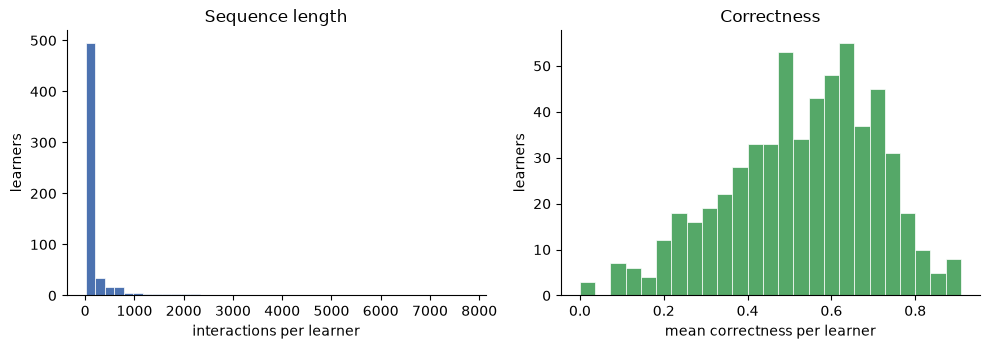

median length 31 | mean correctness 0.529


In [35]:
import matplotlib.pyplot as plt

all_seq = pl.concat([train_seq, val_seq])
seq_lens = all_seq["seq_len"].to_list()
mean_correct = [np.mean(r) for r in all_seq["responses"].to_list()]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].hist(seq_lens, bins=40, color="#4C72B0", edgecolor="white", linewidth=0.5)
ax[0].set(xlabel="interactions per learner", ylabel="learners", title="Sequence length")
ax[1].hist(mean_correct, bins=25, color="#55A868", edgecolor="white", linewidth=0.5)
ax[1].set(xlabel="mean correctness per learner", ylabel="learners", title="Correctness")
for a in ax: a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print(f"median length {int(np.median(seq_lens))} | mean correctness {np.mean(mean_correct):.3f}")